# Ch3 Logistic/Linear Regression

1. Introduction to logistic regression
2. Parameter estimation
3. Estimation through EM algorithm
4. Probabilistic view of Linear Regression

## 1. Introduction to Logistic Regression

### Motivation
Logistic regression is a widely-used statistical method for binary classification problems, where the target variable has two possible outcomes (e.g., 0 or 1, "yes" or "no"). 

Logistic regression **predicts the probability of a class label being positive (1) or negative (0)**.

Common applications of logistic regression include:
- Medical diagnosis (e.g., predicting whether a patient has a certain disease).
- Marketing (e.g., predicting if a customer will buy a product).
- Binary decision processes.


### Logistic Function
The core of logistic regression is the **logistic function** (also known as the **sigmoid function**), which is used to model probabilities. The logistic function is defined as:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Here, $z$ is the linear combination of input features and their corresponding weights:

$$
z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n
$$

This function takes any real-valued number and transforms it into a value between 0 and 1, which can be interpreted as a probability.

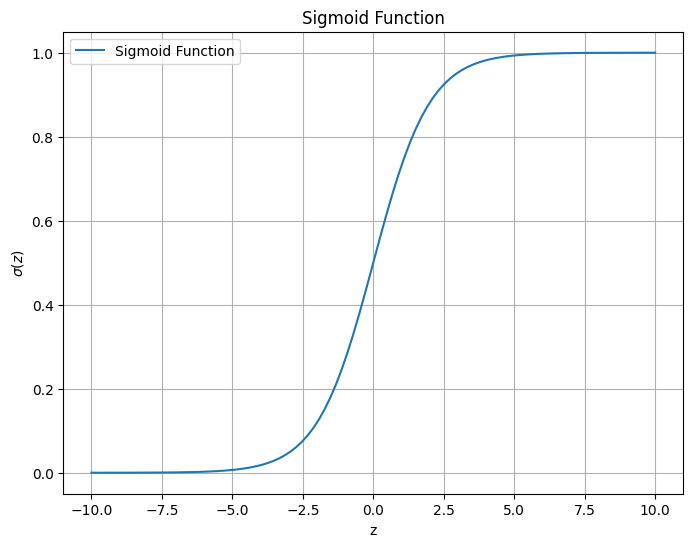

### Model Specification
In logistic regression, the probability $P(y=1 | X)$ is given by the sigmoid function applied to the linear predictor:

$$
P(y=1 | X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \dots + \beta_n x_n)}}
$$

The log-odds (logit) of the probability is modeled as a linear combination of the input features:

$$
\log\left(\frac{P(y=1 | X)}{1 - P(y=1 | X)}\right) = \beta_0 + \beta_1 x_1 + \dots + \beta_n x_n
$$

In this formulation:
- $\beta_0, \beta_1, \dots, \beta_n$ are the parameters (or coefficients) to be estimated.


## 2. Parameter Estimation in Logistic Regression

### Maximum Likelihood Estimation (MLE)

In logistic regression, we estimate the model parameters $\beta_0, \beta_1, \dots, \beta_n$ using **Maximum Likelihood Estimation (MLE)**. 

The **likelihood function is the probability of observing the data given the parameters**, and we aim to maximize this likelihood.

For logistic regression, the likelihood of a single data point is:

$$
L(\beta | x, y) = P(y=1 | x)^{y} \cdot (1 - P(y=1 | x))^{1 - y}
$$

For a dataset of $N$ independent observations, the likelihood function becomes the product of individual likelihoods:

$$
L(\beta) = \prod_{i=1}^{N} P(y_i | x_i)^{y_i} \cdot (1 - P(y_i | x_i))^{1 - y_i}
$$

Instead of maximizing the likelihood directly, we typically maximize the **log-likelihood** (which simplifies calculations):

$$
\ell(\beta) = \sum_{i=1}^{N} \left[ y_i \log(P(y_i | x_i)) + (1 - y_i) \log(1 - P(y_i | x_i)) \right]
$$

We use **optimization algorithms** to find the values of $\beta$ that maximize this log-likelihood function.


**Maximum Likelihood Estimation (MLE) and Information Theory**

The connection between MLE and **information theory** lies in how we measure **uncertainty** and **information** about the outcomes given the model. 

In logistic regression, the log-likelihood function we are maximizing is closely related to the **cross-entropy** loss. 

**Cross-entropy** measures the difference between two probability distributions: the true distribution (actual labels) and the predicted distribution (predicted probabilities from the model).
$$
H(y, \hat{y}) = - \sum_{i=1}^{N} \left[ y_i \log(\hat{y_i}) + (1 - y_i) \log(1 - \hat{y_i}) \right]
$$
This cross-entropy loss is exactly the negative log-likelihood of the logistic regression model. 

In logistic regression, minimizing cross-entropy is also viewed as minimizing the Kullback-Leibler (KL) divergence between the true distribution of labels and the predicted probabilities from the model.

## Exercise: 

program using tensorflow the logistic regression model and fit parameters using the optimization algorithms seen in the course.

Compare the results with standard logistic regression fitting librarires such as statsmodels.

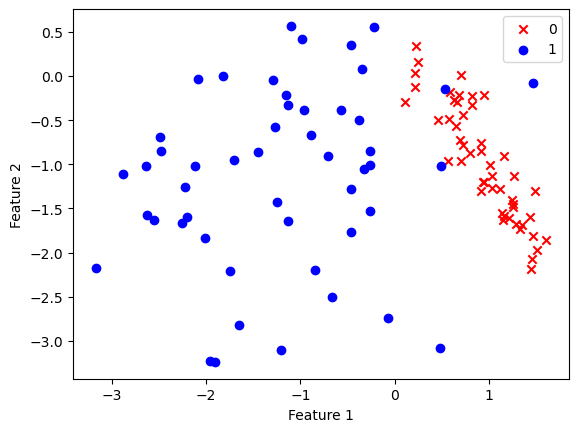

In [4]:
# Generate biary classification data with two features
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
np.random.seed(10)
X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1)

# make_classification genera un conjunto de datos sintéticos para un problema de clasificación binaria.
#   n_samples=100: Genera 100 muestras.
#	n_features=2: Cada muestra tiene 2 características.
#	n_informative=2: Ambas características son informativas, es decir, contribuyen a la clasificación.
#   n_redundant=0: No hay características redundantes (no se genera ninguna característica como combinación de otras).
#   n_clusters_per_class=1: Cada clase (0 y 1) tendrá un solo cluster de puntos.

#   X: Un array de forma (100, 2) que contiene las 100 muestras con 2 características cada una.
#   y: Un array de etiquetas de clase de longitud 100, con valores 0 o 1 (las clases binarias).

plt.scatter(X[y==0][:,0], X[y==0][:,1], c='red', marker='x', label='0')
plt.scatter(X[y==1][:,0], X[y==1][:,1], c='blue', marker='o', label='1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


In [6]:
# fit logistic regression model with statsmodels and show results
# El código entrena un modelo de regresión logística sobre los datos contenidos en X y y
import statsmodels.api as sm

# sm.Logit(y, sm.add_constant(X)): Este código crea un modelo de regresión logística para predecir la variable dependiente y (las etiquetas binarias) a partir de las variables independientes X.
	#•	y: Es el vector de etiquetas (valores binarios, como 0 o 1).
	#•	sm.add_constant(X): Se añade una columna de unos (intercepto) a las variables independientes X, lo que permite que el modelo tenga 
    #                       un término constante (bias) que representa el intercepto de la regresión.
	#•	sm.Logit: Es la clase que se usa para crear un modelo de regresión logística. 
    #             La regresión logística estima la probabilidad de que una observación pertenezca a una de las dos clases (0 o 1) basándose 
    #             en una combinación lineal de las características en X.


# logit_model.fit(): Ajusta el modelo de regresión logística a los datos utilizando un proceso iterativo de máxima verosimilitud. 
# El algoritmo busca los parámetros que mejor ajusten los datos y maximicen la probabilidad de observar los resultados en y dado X. 
# El resultado es un objeto result, que contiene la información del modelo ajustado.
logit_model = sm.Logit(y, sm.add_constant(X))
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.158411
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  100
Model:                          Logit   Df Residuals:                       97
Method:                           MLE   Df Model:                            2
Date:                Sun, 13 Oct 2024   Pseudo R-squ.:                  0.7715
Time:                        08:51:48   Log-Likelihood:                -15.841
converged:                       True   LL-Null:                       -69.315
Covariance Type:            nonrobust   LLR p-value:                 5.980e-24
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2590      0.648      0.400      0.689      -1.012       1.530
x1            -4.7130      1.

In [8]:
# define variables in tensorflow
import tensorflow as tf
#Los convertimos en objetos de tensorflow
X_tf = tf.constant(X, dtype=tf.float32)
y_tf = tf.constant(y, dtype=tf.float32)
# initialize column of betas to true values first
beta = tf.Variable([[0.25], [-4.7], [-1.07]], dtype=tf.float32)

In [9]:
beta

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[ 0.25],
       [-4.7 ],
       [-1.07]], dtype=float32)>

In [12]:
# Binary cross-entropy loss function
import tensorflow as tf

def loss_fn(X, y, beta):
    # Agregar una columna de 1s al principio de la matriz X para el término de sesgo
    valor_uno = tf.ones((X.shape[0], 1), dtype=tf.float32)
    # axis=0: concatenacion a lo largo de filas
    # axis=1: concatenación a lo largo de columnas.
    X1 = tf.concat([valor_uno, X], axis=1)  # X1 tendrá dimensiones (100, 3)

    # Multiplicación matricial entre X1 (100x3) y beta (3x1)
    z = tf.matmul(X1, beta)  # El resultado z será de dimensiones (100, 1)

    # Predicción usando la función sigmoide
    y_pred = tf.sigmoid(z)
    # Es muy importante el reshape. De lo contrario, no va a funcionar
    y_pred = tf.reshape(y_pred, (1,100))

    
    y_tensor=tf.convert_to_tensor(y, dtype=tf.float32)

    y_tensor = tf.reshape(y_tensor, (1, 100))

    # Binary cross-entropy (negative log-likelihood)
    loss = -y * tf.math.log(y_pred) - (1 - y) * tf.math.log(1 - y_pred+10**(-5))
    
    # Retornamos el promedio del loss para todo el dataset
    return tf.reduce_sum(loss)


In [14]:
# verify that the loss function works with the true betas
print(loss_fn(X_tf, y_tf, beta))

tf.Tensor(15.840641, shape=(), dtype=float32)


In [16]:
import numpy as np
import tensorflow as tf

# Generate a synthetic binary classification dataset
n_samples = X.shape[0]
n_features = X.shape[1]

# Convert data to TensorFlow tensors
X_tf = tf.constant(X, dtype=tf.float32)
y_tf = tf.constant(y, dtype=tf.float32)

# Initialize model parameters (beta coefficients) to small values. Ponemos n_features+1 para el beta_0.
beta = tf.Variable(tf.random.normal([n_features+1, 1], dtype=tf.float32)*0.01)


# Binary cross-entropy loss function
def loss_fn(X, y, beta):
     # Agregar una columna de 1s al principio de la matriz X para el término de sesgo
    valor_uno = tf.ones((X.shape[0], 1), dtype=tf.float32)
    X1 = tf.concat([valor_uno, X], axis=1)  # X1 tendrá dimensiones (100, 3)

    # Multiplicación matricial entre X1 (100x3) y beta (3x1)
    z = tf.matmul(X1, beta)  # El resultado z será de dimensiones (100, 1)

    # Predicción usando la función sigmoide
    y_pred = tf.sigmoid(z)

    y_pred = tf.reshape(y_pred, (1,100))

    
    y_tensor=tf.convert_to_tensor(y, dtype=tf.float32)

    y_tensor = tf.reshape(y_tensor, (1, 100))

    # Binary cross-entropy (negative log-likelihood)
    loss = -y * tf.math.log(y_pred) - (1 - y) * tf.math.log(1 - y_pred+10**(-5))
    
    # Retornamos el promedio del loss para todo el dataset
    return tf.reduce_sum(loss)

# Optimizer (Gradient Descent)
optimizer = tf.optimizers.SGD(learning_rate=0.01)


# Training the logistic regression model
num_epochs = 300
for epoch in range(num_epochs):
    # Compute current loss and gradient, Lo que estamos optmizando es beta.
    with tf.GradientTape() as tape:
        loss = loss_fn(X_tf, y_tf, beta)
    gradients = tape.gradient(loss, [beta])
    optimizer.apply_gradients(zip(gradients, [beta]))
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy():.4f}")

# Print final model coefficients (beta)
print(f"Final model coefficients (beta): {beta.numpy().flatten()}")


Epoch 0, Loss: 69.0252
Epoch 100, Loss: 16.1742
Epoch 200, Loss: 15.8901
Final model coefficients (beta): [ 0.22281262 -4.5652876  -1.0241811 ]


In [18]:
#plot probability of class 1 for training data
y_pred = 
plt.scatter(X[:,0], X[:,1], c=y_pred.numpy().flatten(), cmap='coolwarm')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Predicted probability of class 1')
plt.show()


SyntaxError: invalid syntax (793888266.py, line 2)

### Fitting with Stochastic GD

Include Stochastic optimizaition

In [50]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Define batch size for mini-batch SGD
batch_size = 32

# Generate a synthetic binary classification dataset
n_samples = X.shape[0]
n_features = X.shape[1]

# Convert data to TensorFlow tensors
X_tf = tf.constant(X, dtype=tf.float32)
y_tf = tf.constant(y, dtype=tf.float32)

# Initialize model parameters (beta coefficients)
beta = tf.Variable(tf.random.normal([n_features+1, 1], dtype=tf.float32)*0.01)

# Binary cross-entropy loss function
def loss_fn(X, y, beta):
   # Agregar una columna de 1s al principio de la matriz X para el término de sesgo
    valor_uno = tf.ones((X.shape[0], 1), dtype=tf.float32)
    X1 = tf.concat([valor_uno, X], axis=1)  # X1 tendrá dimensiones (100, 3)

    # Multiplicación matricial entre X1 (100x3) y beta (3x1)
    z = tf.matmul(X1, beta)  # El resultado z será de dimensiones (100, 1)

    # Predicción usando la función sigmoide
    y_pred = tf.sigmoid(z)

    #y_pred = tf.reshape(y_pred, (1,32))

    
    y_tensor=tf.convert_to_tensor(y, dtype=tf.float32)

    y_tensor = tf.reshape(y_tensor, (-1, 1))

    # Binary cross-entropy (negative log-likelihood)
    loss = -y * tf.math.log(y_pred) - (1 - y) * tf.math.log(1 - y_pred+10**(-5))
    
    # Retornamos el promedio del loss para todo el dataset
    return tf.reduce_sum(loss)

  
# Training loop with mini-batch gradient descent
num_epochs = 300
num_batches = X.shape[0] // batch_size

# Optimizer (Gradient Descent)
optimizer = tf.optimizers.SGD(learning_rate=0.02)


In [52]:
for epoch in range(num_epochs):
    # Shuffle the training data
    indices = np.random.permutation(len(X))
    X_tf = tf.gather(X_tf, indices)
    y_tf = tf.gather(y_tf, indices)
    
    # Mini-batch SGD
    for i in range(0, X.shape[0], batch_size):
        X_batch = X_tf[i:i+batch_size]
        y_batch = y_tf[i:i+batch_size]
        # Training step (using mini-batches)
        with tf.GradientTape() as tape:
            loss = loss_fn(X_batch, y_batch, beta)
        gradients = tape.gradient(loss, [beta])
        optimizer.apply_gradients(zip(gradients, [beta]))
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy():.4f}")

# Print final model coefficients (beta)
print(f"Final model coefficients (beta): {beta.numpy().flatten()}")

Epoch 0, Loss: 34.1890
Epoch 10, Loss: 83.6793
Epoch 20, Loss: 63.2797
Epoch 30, Loss: 31.6558
Epoch 40, Loss: 34.9879
Epoch 50, Loss: 86.9654
Epoch 60, Loss: 53.4920
Epoch 70, Loss: 14.0950
Epoch 80, Loss: 13.1884
Epoch 90, Loss: 43.5150
Epoch 100, Loss: 72.7278
Epoch 110, Loss: 43.3619
Epoch 120, Loss: 84.7923
Epoch 130, Loss: 1.1267
Epoch 140, Loss: 83.2378
Epoch 150, Loss: 87.4441
Epoch 160, Loss: 118.9557
Epoch 170, Loss: 87.3872
Epoch 180, Loss: 52.4387
Epoch 190, Loss: 137.3724
Epoch 200, Loss: 43.2563
Epoch 210, Loss: 56.9749
Epoch 220, Loss: 38.2886
Epoch 230, Loss: 69.6109
Epoch 240, Loss: 15.9636
Epoch 250, Loss: 41.4089
Epoch 260, Loss: 33.9541
Epoch 270, Loss: 16.4925
Epoch 280, Loss: 46.6011
Epoch 290, Loss: 12.0823
Final model coefficients (beta): [-1.8354104 -1.6897213 -1.7595683]


## 3. Expectation-Maximization (EM) Algorithm for Logistic Regression

### Overview of the EM Algorithm

The **Expectation-Maximization (EM) algorithm** is a powerful method for estimating parameters in models with missing or incomplete data. In situations where some variables are not directly observed, EM iteratively improves the estimation of model parameters by alternating between two key steps: the **Expectation step (E-step)** and the **Maximization step (M-step)**.

In the context of **logistic regression**, the EM algorithm can be applied when there are **missing labels** (i.e., incomplete classification data). The objective is to estimate the model parameters $\beta$ while simultaneously "filling in" the missing labels by treating them as latent (unobserved) variables.

### Steps of the EM Algorithm

1. **Initialization**:
   
   - We start with an initial guess for the model parameters $\beta = (\beta_0, \beta_1, ..., \beta_n)$, typically setting all parameters to zero or initializing them randomly.
   
   - This guess is refined in each iteration of the EM algorithm.



2. **E-Step (Expectation Step)**:
   - In the E-step, we use the current parameter estimates to compute the expected values of the missing data (in our case, the missing class labels).
   - For logistic regression, this involves calculating the probability that a given observation $X_i$ belongs to class 1, i.e., $P(y_i = 1 | X_i, \beta)$, using the **logistic (sigmoid) function**:
   
     $$
     P(y_i = 1 | X_i, \beta) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \dots + \beta_n x_{in})}}
     $$

   - For each data point where the label is missing, we compute this probability and treat it as the **expected value** of the missing label. 
   - Effectively, we are "filling in" the missing labels with their estimated probabilities based on the current model parameters.



3. **M-Step (Maximization Step)**:
   - In the M-step, we maximize the **log-likelihood** of the completed dataset (i.e., the dataset with both the observed and imputed labels) with respect to the parameters $\beta$.
   - This involves solving the following optimization problem:

     $$
     \hat{\beta} = \arg\max_{\beta} \sum_{i=1}^{N} \left[ y_i \log(P(y_i = 1 | X_i, \beta)) + (1 - y_i) \log(1 - P(y_i = 1 | X_i, \beta)) \right]
     $$

   - In this step, the logistic regression parameters are updated to maximize the likelihood of the observed and expected data.
   - We can use numerical optimization methods like **Gradient Descent** or **BFGS** to update $\beta$.


4. **Iteration**:
   - Steps 2 (E-step) and 3 (M-step) are repeated iteratively.
   - After each iteration, the parameters $\beta$ and the imputed labels (computed in the E-step) become more accurate, gradually improving the fit of the model.
   - The algorithm continues until **convergence**, which occurs when the changes in the parameters $\beta$ between iterations become very small (or after a set number of iterations).

5. **Convergence**:
   - The EM algorithm typically converges when the likelihood no longer improves significantly between iterations, or after a predetermined number of iterations.
   - At convergence, the final parameter estimates $\hat{\beta}$ are used to make predictions on new data.

### Applying EM to Logistic Regression with Missing Labels

In logistic regression, the EM algorithm helps us deal with missing labels. Here's how it works step-by-step:

- **Initial Model Parameters ($\beta$)**: We start with an initial guess for $\beta$, often setting the coefficients to zero.
  
- **E-step**: For each observation with a missing label, we compute the probability that the observation belongs to the positive class ($y = 1$) using the current estimates of $\beta$. This probability is the expected value of the missing label, which we use to "fill in" the missing data.

- **M-step**: Once the missing labels are filled, we update the model by finding the parameter values $\beta$ that maximize the likelihood of the completed data (both observed and expected labels). This is done through an optimization procedure, such as the BFGS algorithm or gradient descent.

- **Iteration**: We repeat the E-step and M-step iteratively, refining the model parameters and the imputed labels until the parameters converge.

### Example: Logistic Regression with Missing Labels using EM

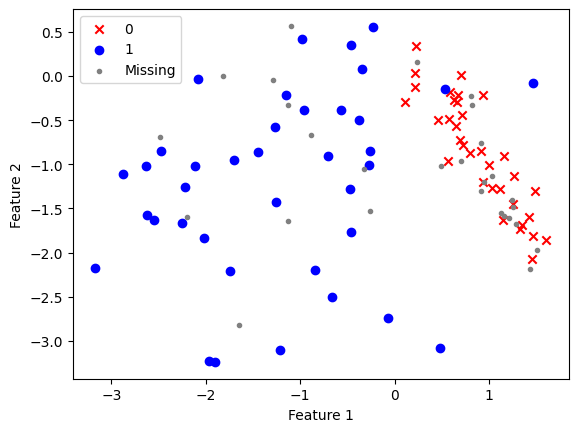

In [37]:
# Generate a synthetic binary classification dataset with some missing labels
np.random.seed(42)
# Introduce missing labels in 20% of the dataset
missing_mask = np.random.rand(len(y)) < 0.2  # 20% of labels are missing
y_observed = np.copy(y)
y_observed[missing_mask] = -1  # Mark missing labels as -1

# Plot the data with missing labels
plt.scatter(X[y_observed==0][:,0], X[y_observed==0][:,1], c='red', marker='x', label='0')
plt.scatter(X[y_observed==1][:,0], X[y_observed==1][:,1], c='blue', marker='o', label='1')
plt.scatter(X[y_observed==-1][:,0], X[y_observed==-1][:,1], c='gray', marker='.', label='Missing')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


In [ ]:
# plot probability of class 1 for training data
def plot_probability(X, beta, y_observed):
    y_pred = ### calculate predicted probabilities
    plt.scatter(X[:,0], X[:,1], c=y_pred.numpy().flatten(), cmap='coolwarm')
    # mark missing labels
    plt.scatter(X[y_observed==-1][:,0], X[y_observed==-1][:,1], c='gray', marker='.', label='Missing')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.colorbar(label='Predicted probability of class 1')
    plt.show()


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Binary cross-entropy loss function
def loss_fn(X, y, beta):
    ### complete the loss function

In [ ]:
# E-step: Compute the expected values for the missing labels
def e_step(X, beta, y_observed, missing_mask):
    y_pred = # Predict probabilities for data
    
    # Create copy of observed labels and fill in missing labels with predicted probabilities
    y_completed = np.copy(y_observed)
    y_completed[missing_mask] = y_pred.numpy()[missing_mask].flatten()  # Fill missing labels with predicted probabilities
    return y_completed

In [ ]:
# M-step: Optimize the log-likelihood with respect to beta
def m_step(X, y_completed, beta):
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
    
    # Perform optimization
    num_epochs = 300
    for epoch in range(num_epochs):
        with tf.GradientTape() as tape:
            loss = loss_fn(X, y_completed, beta)
        gradients = tape.gradient(loss, [beta])
        optimizer.apply_gradients(zip(gradients, [beta]))
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss.numpy():.4f}")
    
    return beta

In [ ]:

# Initialize model parameters (beta coefficients)
beta = tf.Variable(tf.random.normal([n_features+1, 1], dtype=tf.float32)*0.01)

# EM Algorithm
for iteration in range(5):  # Perform up to 100 iterations
    
    print(f"Iteration {iteration}")
    
    # visualize the probability of class 1 for training data
    plot_probability(X, beta, y_observed)
    
    # E-step: Fill in the missing labels
    y_completed = e_step(X, beta, y_observed, missing_mask)
    
    # Set y_completed as a TensorFlow constant
    y_completed = tf.constant(y_completed, dtype=tf.float32)
    # M-step: Update the model parameters based on the completed dataset
    beta = m_step(X, y_completed, beta)

# Final estimated beta values after convergence
print(f"Estimated coefficients after EM: {beta.numpy().flatten()}")

## Why Use the EM Algorithm?

The EM algorithm is useful in logistic regression when some labels are missing because:
- It provides a way to iteratively estimate both the model parameters and the missing data.
- Unlike standard logistic regression, which assumes complete data, EM can handle the uncertainty due to missing labels.
- The algorithm tends to converge to a **local maximum** of the likelihood, ensuring that the estimates are as accurate as possible given the data.

## 4. Probabilistic View of Linear Regression

In linear regression, we model the relationship between a continuous response variable $ y $ and one or more explanatory variables $ X $. The goal is to find the parameters $ \beta $ that best explain the observed data. 

### The Linear Model

The basic form of the linear regression model is:
$$
y = X \beta + \epsilon
$$
Where:
- $ y $ is the vector of observed responses.
- $ X $ is the design matrix of explanatory variables (features), with each row representing one observation and each column representing one feature.
- $ \beta $ is the vector of model parameters (coefficients), where each $ \beta_j $ corresponds to the contribution of feature $ X_j $ to the response $ y $.
- $ \epsilon $ is the error term or residual, which represents the deviation of the observed values from the true regression line.



### Probabilistic Assumptions

Linear regression assumes the following probabilistic structure:

1. **Gaussian Distribution of Errors**:
   The errors $ \epsilon_i $ are assumed to be independent and normally distributed with mean zero and constant variance $ \sigma^2 $:
   $$
   \epsilon_i \sim \mathcal{N}(0, \sigma^2)
   $$
   This means that for each observation $ y_i $, the response is distributed as:
   $$
   y_i | X_i, \beta \sim \mathcal{N}(X_i \beta, \sigma^2)
   $$
   Where $ X_i \beta $ is the linear predictor, and $ \sigma^2 $ is the variance of the noise.



2. **Likelihood of the Data**:
   Given the assumption of normally distributed errors, the likelihood of observing the data given the parameters $ \beta $ and $ \sigma^2 $ is:
   $$
   L(\beta, \sigma^2 | X, y) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi \sigma^2}} \exp\left( - \frac{(y_i - X_i \beta)^2}{2\sigma^2} \right)
   $$
   The goal of linear regression is to estimate the parameters $ \beta $ and $ \sigma^2 $ that maximize this likelihood.



3. **Maximum Likelihood Estimation (MLE)**:
   In practice, we estimate $ \beta $ by maximizing the likelihood or equivalently, minimizing the negative log-likelihood. The negative log-likelihood for the Gaussian model is:
   $$
   -\log L(\beta, \sigma^2 | X, y) = \frac{n}{2} \log(2\pi \sigma^2) + \frac{1}{2\sigma^2} \sum_{i=1}^{n} (y_i - X_i \beta)^2
   $$
   Minimizing this expression with respect to $ \beta $ (assuming $ \sigma^2 $ is constant) leads to the familiar **Ordinary Least Squares (OLS)** solution, where we minimize the **sum of squared residuals**:
   $$
   \hat{\beta} = \arg \min_{\beta} \sum_{i=1}^{n} (y_i - X_i \beta)^2
   $$




4. **Uncertainty in Predictions**:
   Because the error term $ \epsilon_i $ is normally distributed, we can express uncertainty in predictions. The predicted response for a new observation $ X_{\text{new}} $ follows a normal distribution:
   $$
   y_{\text{new}} | X_{\text{new}}, \beta \sim \mathcal{N}(X_{\text{new}} \beta, \sigma^2)
   $$
   This provides confidence intervals and prediction intervals for the predictions of $ y $.


## Exercise: 

program using tensorflow the linear regression model and fit parameters using the optimization algorithms seen in the course.

Compare the results with standard linear regression fitting librarires such as statsmodels.

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Generate a synthetic dataset for linear regression
X, y = make_regression(n_samples=500, n_features=2, noise=10, random_state=42)

In [ ]:
#fit linear regression model with statsmodels and show results
import statsmodels.api as sm
ols_model = sm.OLS(y, sm.add_constant(X))
result = ols_model.fit()
print(result.summary())


In [ ]:
# Convert the data to TensorFlow tensors
X_tf = tf.constant(X, dtype=tf.float32)
y_tf = tf.constant(y, dtype=tf.float32)

# Initialize the model parameters (beta coefficients)
beta = tf.Variable(tf.random.normal([X_tf.shape[1]+1, 1], dtype=tf.float32))

# Define the linear regression model
def linear_model(X):
    return beta[0]+tf.matmul(X, beta[1:])

# Loss function: Mean Squared Error (MSE)
def loss_fn(X, y):
    y_pred = linear_model(X)
    return tf.reduce_mean(tf.square(y_pred - y[:, None]))

# Optimizer: Gradient Descent
optimizer = tf.optimizers.SGD(learning_rate=0.01)

# Training loop
num_epochs = 300
for epoch in range(num_epochs):
    with tf.GradientTape() as tape:
        loss = loss_fn(X_tf, y_tf)
    gradients = tape.gradient(loss, [beta])
    optimizer.apply_gradients(zip(gradients, [beta]))
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy():.4f}")

# Print final model coefficients (beta)
print(f"Final model coefficients: {beta.numpy().flatten()}")

**How about $\sigma$?**